In [4]:
import tensorflow as tf
print(tf.config.list_physical_devices('GPU'))

[PhysicalDevice(name='/physical_device:GPU:0', device_type='GPU')]


In [5]:
import tensorflow as tf
from tensorflow.keras.preprocessing.image import ImageDataGenerator
import matplotlib.pyplot as plt

In [6]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import (
    Input,
    Conv2D,
    MaxPooling2D,
    Flatten,
    Dense,
    Dropout
)

model = Sequential([
    Input(shape=(48, 48, 1)),

    Conv2D(32, (3, 3), activation='relu'),
    MaxPooling2D(2, 2),

    Conv2D(64, (3, 3), activation='relu'),
    MaxPooling2D(2, 2),

    Flatten(),

    Dense(128, activation='relu'),
    Dropout(0.5),

    Dense(7, activation='softmax')
])

model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 46, 46, 32)     │           320 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 23, 23, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 21, 21, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 10, 10, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 6400)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 128)            │       819,328 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 7)              │           903 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 839,047 (3.20 MB)

 Trainable params: 839,047 (3.20 MB)

 Non-trainable params: 0 (0.00 B)

In [7]:
train_dir = "train"
test_dir = "test"

In [8]:
train_datagen = ImageDataGenerator(
    rescale=1./255
)

test_datagen = ImageDataGenerator(
    rescale=1./255
)

In [9]:
train_generator = train_datagen.flow_from_directory(
    train_dir,
    target_size=(48, 48),
    color_mode='grayscale',
    batch_size=32,
    class_mode='categorical'
)

Found 28709 images belonging to 7 classes.


In [10]:
test_generator = test_datagen.flow_from_directory(
    test_dir,
    target_size=(48, 48),
    color_mode='grayscale',
    batch_size=32,
    class_mode='categorical'
)

Found 7178 images belonging to 7 classes.


In [2]:
images, labels = next(train_generator)

print(images.shape)
print(labels.shape)

NameError: name 'train_generator' is not defined

In [11]:
model.compile(
    optimizer='adam',
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

In [12]:
history = model.fit(
    train_generator,
    validation_data=test_generator,
    epochs=15
)

Epoch 1/15
898/898 ━━━━━━━━━━━━━━━━━━━━ 21s 18ms/step - accuracy: 0.3246 - loss: 1.6880 - val_accuracy: 0.4164 - val_loss: 1.5449
Epoch 2/15
898/898 ━━━━━━━━━━━━━━━━━━━━ 13s 15ms/step - accuracy: 0.4283 - loss: 1.4893 - val_accuracy: 0.4518 - val_loss: 1.4130
Epoch 3/15
898/898 ━━━━━━━━━━━━━━━━━━━━ 13s 14ms/step - accuracy: 0.4586 - loss: 1.4060 - val_accuracy: 0.4781 - val_loss: 1.3598
Epoch 4/15
898/898 ━━━━━━━━━━━━━━━━━━━━ 13s 15ms/step - accuracy: 0.4840 - loss: 1.3472 - val_accuracy: 0.4948 - val_loss: 1.3270
Epoch 5/15
898/898 ━━━━━━━━━━━━━━━━━━━━ 13s 15ms/step - accuracy: 0.5065 - loss: 1.2890 - val_accuracy: 0.5116 - val_loss: 1.2641
Epoch 6/15
898/898 ━━━━━━━━━━━━━━━━━━━━ 13s 15ms/step - accuracy: 0.5221 - loss: 1.2433 - val_accuracy: 0.5181 - val_loss: 1.2529
Epoch 7/15
898/898 ━━━━━━━━━━━━━━━━━━━━ 13s 15ms/step - accuracy: 0.5389 - loss: 1.2032 - val_accuracy: 0.5196 - val_loss: 1.2338
Epoch 8/15
898/898 ━━━━━━━━━━━━━━━━━━━━ 13s 15ms/step - accuracy: 0.5522 - loss: 1.1631 - 

In [13]:
mkdir -p ~/.kaggle && echo KGAT_784fb46f22c044618e6778d5bd6a7107 > ~/.kaggle/access_token && chmod 600 ~/.kaggle/access_token

In [ ]:
!kaggle datasets download -d msambare/fer2013
!unzip fer2013.zip

In [14]:
model.save("emotion_model.keras")

In [15]:
from google.colab import files
files.download("emotion_model.keras")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

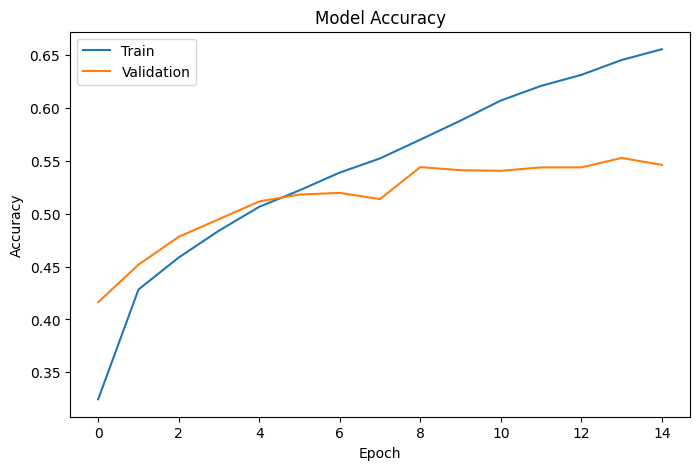

In [16]:
plt.figure(figsize=(8,5))
plt.plot(history.history['accuracy'])
plt.plot(history.history['val_accuracy'])
plt.title('Model Accuracy')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.legend(['Train', 'Validation'])
plt.show()

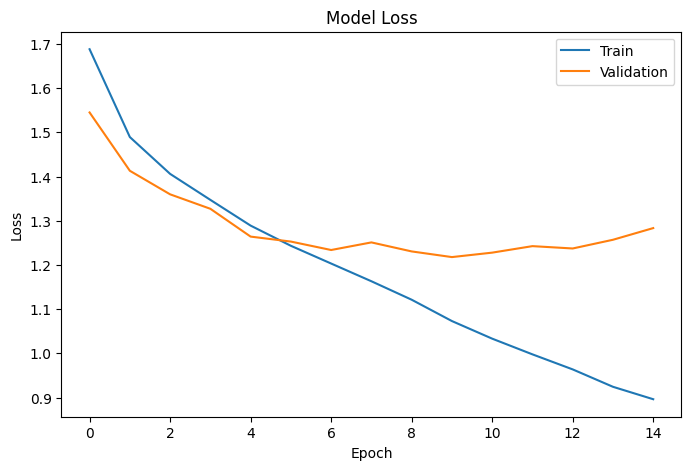

In [17]:
plt.figure(figsize=(8,5))
plt.plot(history.history['loss'])
plt.plot(history.history['val_loss'])
plt.title('Model Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend(['Train', 'Validation'])
plt.show()

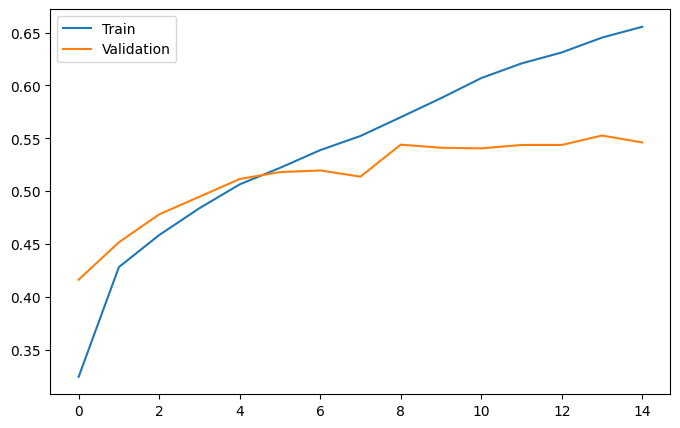

In [18]:
plt.figure(figsize=(8,5))
plt.plot(history.history['accuracy'])
plt.plot(history.history['val_accuracy'])
plt.legend(['Train', 'Validation'])
plt.savefig('accuracy.png')

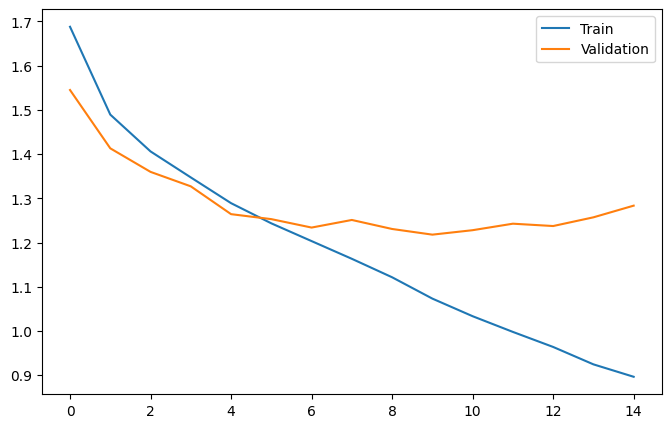

In [19]:
plt.figure(figsize=(8,5))
plt.plot(history.history['loss'])
plt.plot(history.history['val_loss'])
plt.legend(['Train', 'Validation'])
plt.savefig('loss.png')

In [20]:
files.download('accuracy.png')
files.download('loss.png')

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>